# ARC_ATLAS v4 Small-Lesion Runbook

This notebook runs the current small-lesion training variant, but it is intentionally kept close to the last strong baseline.

## Active Small-Lesion Measures
- Source-balanced case sampling.
- Small-lesion-aware case grouping: `1-99`, `100-999`, `1000-9999`, `10000+` voxels.
- Mild tiny-lesion-biased foreground patch sampling.
- Generic spatial/intensity augmentation on all patches, including small-lesion cases.
- Lower-learning-rate, long-horizon training schedule with regularization.
- Whole-brain validation every epoch with:
  - soft Dice
  - raw hard Dice before any masking
  - brain-mask-clipped hard Dice
  - full postprocessed hard Dice
  - brain-mask clipping is OFF for the main prediction by default; the clipped mask is logged only as a diagnostic comparator
  - brain-mask and postprocessing deltas
  - threshold sweep
  - per-source metrics
  - per-case CSV diagnostics
  - grouped CV fold diagnostics
  - tiny-lesion hit/miss counts

## Intentionally Disabled In This Run
- Auxiliary MSL/DBL label heads.
- TopK hard-voxel loss.
- Lesion insertion augmentation.
- Symmetric flip extra input channel.
- Brain-mask clipping in the main prediction/postprocessing path.
- Component-scoring postprocessing.
- Component-aware patch centering.

## Current Goal
- Best-checkpoint selection now monitors `val_whole_dice_hard_raw`.
Keep the model close to the older working baseline while preserving stronger diagnostics and a mild small-lesion sampling bias.

## Diagnostics Written Per Run
- `callbacks/training_log.csv`
- `callbacks/batch_metrics.csv`
- `callbacks/epoch_metrics.jsonl`
- `callbacks/whole_val_summary.jsonl`
- `callbacks/whole_val_epoch_XXXX.csv`
- `callbacks/diagnostics/split_cases.csv`
- `callbacks/diagnostics/split_summary.json`
- `callbacks/diagnostics/grouped_cv_folds.csv`
- `callbacks/diagnostics/training_summary.json`
- `callbacks/diagnostics/training_summary.md`




2026-04-03 13:05:49.048405: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision policy: <DTypePolicy "float32">
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1775243150.821396  130081 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1775243150.822441  130081 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14740 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:41:00.0, compute capability: 8.9
I0000 00:00:1775243150.822781  130081 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 1
I0000 00:00:1775243150.823771  130081 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14651 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:61:00.0, compute capability: 8.9
2026-04-03 13:05:50,891 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2026-04-03 13:05:50,892 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2026-04-03 13:05:50,892 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]
- TensorFlo

Strategy: MirroredStrategy
Ignoring stale runs/latest -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260226_113444 because it lacks diagnostics/checkpoints needed by this cell.
Selected debug run: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260401_162909
Using validation diagnostics: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260401_162909/callbacks/whole_val_epoch_0046.csv
Selected ATLAS case from latest diagnostics: ATLAS-Images-f0d7431e__sub-r038s078_ses-1_space-MNI152NLin2009aSym_T1w_MNI_norm
source: ATLAS-Images-f0d7431e
logged hard_dice: 0.2731606696355767
logged hard_dice_raw: 0.38772307529843847
logged hard_dice_brainmask: N/A in this run
Run dir: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260401_162909
Image: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/90_10_random/train/t1/ATLAS-Images-f0d7431e__sub-r038s078_ses-1_sp

2026-04-03 13:05:53.469930: I external/local_xla/xla/service/service.cc:163] XLA service 0x77ddbc009880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-03 13:05:53.469968: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-03 13:05:53.469975: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-03 13:05:53.543160: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-03 13:05:53.801987: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91001
2026-04-03 13:05:54.216511: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, 

Slice: 147
Dice raw       : 0.47742 voxels: 181394
Dice brainmask : 0.35749 voxels: 120396
Dice postproc  : 0.35749 voxels: 120396
Brain-mask removed voxels: 60998
Component postproc removed voxels: 0
True lesion voxels: 225183


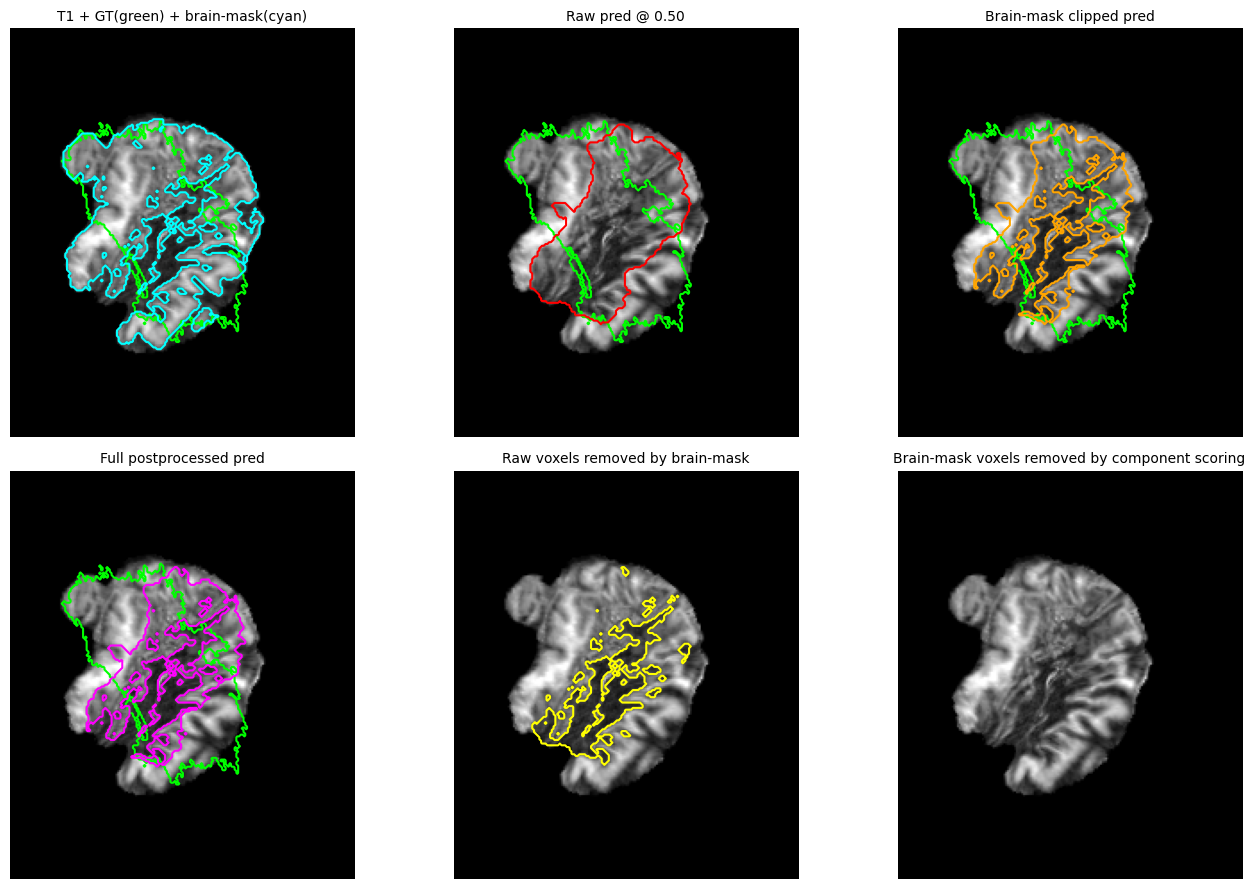

In [1]:
# --------- ATLAS raw vs brain-mask vs postprocessing debug viewer ---------
# Run this cell to inspect one ATLAS validation case and see whether brain-mask clipping
# or postprocessing is deleting lesion predictions that the raw probability map had.
# Avoid running this while another training job is actively using the same GPUs.

from pathlib import Path
from dataclasses import fields as dc_fields
import importlib.util
import csv
import json
import numpy as np
import matplotlib.pyplot as plt

DEBUG_PROJECT_ROOT = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DEBUG_SRC = DEBUG_PROJECT_ROOT / "src" / "training_v2_smalllesion.py"
DEBUG_RUNS_ROOT = DEBUG_PROJECT_ROOT / "runs"
DEBUG_THRESHOLD = 0.50
DEBUG_FORCE_COMPONENT_POSTPROC = None  # None = use the run config; True/False = override component scoring only

spec_dbg = importlib.util.spec_from_file_location("seg_small_debug", DEBUG_SRC)
if spec_dbg is None or spec_dbg.loader is None:
    raise RuntimeError(f"Could not load module spec from {DEBUG_SRC}")
seg_dbg = importlib.util.module_from_spec(spec_dbg)
spec_dbg.loader.exec_module(seg_dbg)

DEBUG_RUN_DIR_OVERRIDE = None  # Example: Path("/home/rbielski/.../runs/20260401_162909")


def _debug_run_has_checkpoint(run_dir):
    cb = run_dir / "callbacks"
    return (cb / "best_model_dynamic.weights.h5").exists() or (cb / "latest.weights.h5").exists()


def _debug_run_has_case_diagnostics(run_dir):
    return (
        (run_dir / "models" / "config.json").exists()
        and _debug_run_has_checkpoint(run_dir)
        and (
            any((run_dir / "callbacks").glob("whole_val_epoch_*.csv"))
            or (run_dir / "callbacks" / "diagnostics" / "split_cases.csv").exists()
        )
    )


def _debug_run_score(run_dir):
    cb = run_dir / "callbacks"
    mtimes = [
        (cb / "training_log.csv").stat().st_mtime if (cb / "training_log.csv").exists() else 0,
        (cb / "whole_val_summary.jsonl").stat().st_mtime if (cb / "whole_val_summary.jsonl").exists() else 0,
        (cb / "best_model_dynamic.weights.h5").stat().st_mtime if (cb / "best_model_dynamic.weights.h5").exists() else 0,
        (cb / "latest.weights.h5").stat().st_mtime if (cb / "latest.weights.h5").exists() else 0,
        run_dir.stat().st_mtime,
    ]
    return (max(mtimes), run_dir.name)


if DEBUG_RUN_DIR_OVERRIDE is not None:
    DEBUG_RUN_DIR = Path(DEBUG_RUN_DIR_OVERRIDE).expanduser().resolve()
    if not _debug_run_has_case_diagnostics(DEBUG_RUN_DIR):
        raise FileNotFoundError(
            f"DEBUG_RUN_DIR_OVERRIDE does not have whole_val_epoch_*.csv or diagnostics/split_cases.csv plus a checkpoint: {DEBUG_RUN_DIR}"
        )
else:
    latest_link = DEBUG_RUNS_ROOT / "latest"
    latest_target = latest_link.resolve() if (latest_link.exists() or latest_link.is_symlink()) else None
    if latest_target is not None and _debug_run_has_case_diagnostics(latest_target):
        DEBUG_RUN_DIR = latest_target
    else:
        run_candidates = [d for d in DEBUG_RUNS_ROOT.iterdir() if d.is_dir() and _debug_run_has_case_diagnostics(d)]
        if not run_candidates:
            raise FileNotFoundError(
                f"No run directories with models/config.json + checkpoint + whole_val_epoch_*.csv or diagnostics/split_cases.csv under {DEBUG_RUNS_ROOT}"
            )
        DEBUG_RUN_DIR = max(run_candidates, key=_debug_run_score)
        if latest_target is not None:
            print(f"Ignoring stale runs/latest -> {latest_target} because it lacks diagnostics/checkpoints needed by this cell.")

print("Selected debug run:", DEBUG_RUN_DIR)

cfg_path_dbg = DEBUG_RUN_DIR / "models" / "config.json"
raw_cfg_dbg = json.load(open(cfg_path_dbg))
path_fields_dbg = {
    "DATA_DIR", "IMAGES_DIR", "MASKS_DIR", "MODEL_DIR", "CALLBACKS_DIR",
    "EXTERNAL_VAL_DIR", "EXTERNAL_VAL_IMAGES_DIR", "EXTERNAL_VAL_MASKS_DIR", "EXTERNAL_VAL_MANIFEST",
}
cfg_kwargs_dbg = {}
for f in dc_fields(seg_dbg.DynamicTrainingConfig):
    if not f.init or f.name not in raw_cfg_dbg or raw_cfg_dbg[f.name] is None:
        continue
    value = raw_cfg_dbg[f.name]
    if f.name in path_fields_dbg:
        value = Path(value)
    elif isinstance(value, list):
        value = tuple(value)
    cfg_kwargs_dbg[f.name] = value
cfg_kwargs_dbg["MODEL_DIR"] = Path("/tmp/smartsota_atlas_brainmask_debug/models")
cfg_kwargs_dbg["CALLBACKS_DIR"] = Path("/tmp/smartsota_atlas_brainmask_debug/callbacks")
cfg_dbg = seg_dbg.DynamicTrainingConfig(**cfg_kwargs_dbg)
cfg_dbg.DECISION_THRESHOLD = float(DEBUG_THRESHOLD)

weights_dbg = DEBUG_RUN_DIR / "callbacks" / "best_model_dynamic.weights.h5"
if not weights_dbg.exists():
    weights_dbg = DEBUG_RUN_DIR / "callbacks" / "latest.weights.h5"
if not weights_dbg.exists():
    raise FileNotFoundError(f"No checkpoint found in {DEBUG_RUN_DIR / 'callbacks'}")

whole_epoch_csvs = sorted((DEBUG_RUN_DIR / "callbacks").glob("whole_val_epoch_*.csv"))
rows_dbg = []
if whole_epoch_csvs:
    latest_epoch_csv_dbg = whole_epoch_csvs[-1]
    rows_dbg = [r for r in csv.DictReader(open(latest_epoch_csv_dbg)) if r.get("source", "").startswith("ATLAS")]
    print("Using validation diagnostics:", latest_epoch_csv_dbg)
else:
    latest_epoch_csv_dbg = None

if rows_dbg:
    def _gap_score(row):
        raw_val = float(row.get("hard_dice_raw", row.get("hard_dice", 0.0)) or 0.0)
        if "hard_dice_brainmask" in row and row.get("hard_dice_brainmask") not in (None, ""):
            clipped_val = float(row.get("hard_dice_brainmask") or 0.0)
        else:
            clipped_val = float(row.get("hard_dice") or 0.0)
        return raw_val - clipped_val

    chosen_row_dbg = max(rows_dbg, key=_gap_score)
    img_p_dbg = Path(chosen_row_dbg["image"])
    msk_p_dbg = Path(chosen_row_dbg["mask"])
    print("Selected ATLAS case from latest diagnostics:", chosen_row_dbg.get("case_id"))
    print("source:", chosen_row_dbg.get("source"))
    print("logged hard_dice:", chosen_row_dbg.get("hard_dice"))
    print("logged hard_dice_raw:", chosen_row_dbg.get("hard_dice_raw"))
    print("logged hard_dice_brainmask:", chosen_row_dbg.get("hard_dice_brainmask", "N/A in this run"))
else:
    split_csv_dbg = DEBUG_RUN_DIR / "callbacks" / "diagnostics" / "split_cases.csv"
    if not split_csv_dbg.exists():
        raise FileNotFoundError(f"Could not find ATLAS val rows. Missing {split_csv_dbg}")
    split_rows_dbg = [r for r in csv.DictReader(open(split_csv_dbg)) if r.get("split") == "val" and r.get("source", "").startswith("ATLAS")]
    if not split_rows_dbg:
        raise RuntimeError(f"No ATLAS validation rows in {split_csv_dbg}")
    chosen_row_dbg = split_rows_dbg[0]
    img_p_dbg = Path(chosen_row_dbg["image"])
    msk_p_dbg = Path(chosen_row_dbg["mask"])
    print("Selected ATLAS case from split diagnostics:", chosen_row_dbg.get("case_id"))

print("Run dir:", DEBUG_RUN_DIR)
print("Image:", img_p_dbg)
print("Mask :", msk_p_dbg)
print("Checkpoint:", weights_dbg)

model_dbg = seg_dbg.build_model_for_inference(cfg_dbg, weights_path=str(weights_dbg))
vol_shape_dbg = seg_dbg._full_volume_target_shape(cfg_dbg)
x_dbg = seg_dbg._load_and_preprocess_image(str(img_p_dbg), vol_shape_dbg)
y_dbg = seg_dbg._load_and_preprocess_mask(str(msk_p_dbg), vol_shape_dbg).astype(np.float32)
probs_dbg = seg_dbg.gaussian_tta_predict(
    model_dbg,
    x_dbg,
    patch_size=tuple(cfg_dbg.PATCH_SIZE or cfg_dbg.INPUT_SHAPE[:-1]),
    overlap=float(cfg_dbg.GAUSSIAN_TILE_OVERLAP),
    sigma=float(cfg_dbg.GAUSSIAN_TILE_SIGMA),
    tta=bool(cfg_dbg.WHOLE_BRAIN_VAL_TTA),
)
probs_dbg = np.clip(np.nan_to_num(probs_dbg, nan=0.0, posinf=0.0, neginf=0.0), 0.0, 1.0).astype(np.float32, copy=False)
brain_mask_dbg = seg_dbg.compute_brain_mask(x_dbg).astype(np.float32)
raw_mask_dbg = (probs_dbg >= DEBUG_THRESHOLD).astype(np.float32)
brainmask_mask_dbg = seg_dbg.apply_postprocessing(
    probs_dbg,
    threshold=DEBUG_THRESHOLD,
    min_size=0,
    closing=0,
    use_component_scoring=False,
    brain_mask=brain_mask_dbg,
    clamp=cfg_dbg.OTSU_CLAMP,
    min_prob=cfg_dbg.OTSU_MIN_PROB,
).astype(np.float32)

postproc_use_components_dbg = (
    bool(cfg_dbg.USE_COMPONENT_SCORING_POSTPROC)
    if DEBUG_FORCE_COMPONENT_POSTPROC is None
    else bool(DEBUG_FORCE_COMPONENT_POSTPROC)
)
postproc_brain_mask_dbg = brain_mask_dbg if bool(getattr(cfg_dbg, "USE_BRAINMASK_POSTPROC", False)) else None
postproc_mask_dbg = seg_dbg.apply_postprocessing(
    probs_dbg,
    threshold=DEBUG_THRESHOLD,
    min_size=0,
    closing=0,
    use_component_scoring=postproc_use_components_dbg,
    brain_mask=postproc_brain_mask_dbg,
    clamp=cfg_dbg.OTSU_CLAMP,
    min_prob=cfg_dbg.OTSU_MIN_PROB,
).astype(np.float32)

def dice_dbg(a, b):
    a = (np.asarray(a) > 0.5).astype(np.float32)
    b = (np.asarray(b) > 0.5).astype(np.float32)
    return float((2.0 * np.sum(a * b) + 1e-6) / (np.sum(a) + np.sum(b) + 1e-6))

removed_by_brainmask_dbg = np.clip(raw_mask_dbg - brainmask_mask_dbg, 0.0, 1.0)
removed_by_postproc_dbg = np.clip(brainmask_mask_dbg - postproc_mask_dbg, 0.0, 1.0)
score_per_slice_dbg = (
    4.0 * y_dbg.sum(axis=(1, 2))
    + 2.0 * removed_by_brainmask_dbg.sum(axis=(1, 2))
    + 2.0 * removed_by_postproc_dbg.sum(axis=(1, 2))
    + raw_mask_dbg.sum(axis=(1, 2))
)
slice_idx_dbg = int(np.argmax(score_per_slice_dbg)) if score_per_slice_dbg.size else int(x_dbg.shape[0] // 2)

print("Slice:", slice_idx_dbg)
print("Dice raw       :", round(dice_dbg(y_dbg, raw_mask_dbg), 5), "voxels:", int(raw_mask_dbg.sum()))
print("Dice brainmask :", round(dice_dbg(y_dbg, brainmask_mask_dbg), 5), "voxels:", int(brainmask_mask_dbg.sum()))
print("Dice postproc  :", round(dice_dbg(y_dbg, postproc_mask_dbg), 5), "voxels:", int(postproc_mask_dbg.sum()))
print("Brain-mask removed voxels:", int(removed_by_brainmask_dbg.sum()))
print("Component/full-postproc removed voxels:", int(removed_by_postproc_dbg.sum()))
print("Full postproc uses brain mask:", bool(postproc_brain_mask_dbg is not None))
print("Full postproc uses component scoring:", bool(postproc_use_components_dbg))
print("True lesion voxels:", int((y_dbg > 0.5).sum()))

def _draw_overlay(ax, bg, masks, title):
    ax.imshow(bg, cmap="gray")
    for arr, color, label in masks:
        if np.any(arr > 0.5):
            ax.contour(arr > 0.5, levels=[0.5], colors=[color], linewidths=1.5)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

z = slice_idx_dbg
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
_draw_overlay(axes[0, 0], x_dbg[z], [(y_dbg[z], "lime", "GT"), (brain_mask_dbg[z], "cyan", "brain")], "T1 + GT(green) + brain-mask(cyan)")
_draw_overlay(axes[0, 1], x_dbg[z], [(y_dbg[z], "lime", "GT"), (raw_mask_dbg[z], "red", "raw")], f"Raw pred @ {DEBUG_THRESHOLD:.2f}")
_draw_overlay(axes[0, 2], x_dbg[z], [(y_dbg[z], "lime", "GT"), (brainmask_mask_dbg[z], "orange", "brainmask")], "Brain-mask clipped pred")
_draw_overlay(axes[1, 0], x_dbg[z], [(y_dbg[z], "lime", "GT"), (postproc_mask_dbg[z], "magenta", "postproc")], f"Full postprocessed pred\nbrainmask={bool(postproc_brain_mask_dbg is not None)}, cc={bool(postproc_use_components_dbg)}")
_draw_overlay(axes[1, 1], x_dbg[z], [(removed_by_brainmask_dbg[z], "yellow", "removed")], "Raw voxels removed by brain-mask")
_draw_overlay(axes[1, 2], x_dbg[z], [(removed_by_postproc_dbg[z], "yellow", "removed")], "Brain-mask voxels removed by component scoring")
plt.tight_layout()
plt.show()

# Free model memory before training in this notebook.
del model_dbg



In [ ]:
from pathlib import Path
import importlib.util
import shutil
import time
import traceback

# --------- Paths and module loading ---------
PROJECT_ROOT = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
RUN_ROOT = PROJECT_ROOT
SRC = PROJECT_ROOT / "src" / "training_v2_smalllesion.py"

TRAIN_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/90_10_random/train")
TRAIN_T1 = TRAIN_DIR / "t1"
TRAIN_MASKS = TRAIN_DIR / "masks"

if not SRC.exists():
    raise FileNotFoundError(f"Training module not found: {SRC}")
if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"Training data dir not found: {TRAIN_DIR}. Run ARC_ATLAS_TrainPrep_v4.ipynb first.")
if not TRAIN_T1.exists() or not TRAIN_MASKS.exists():
    raise FileNotFoundError(f"Expected subfolders missing under {TRAIN_DIR}: t1/ and masks/")

spec = importlib.util.spec_from_file_location("seg", SRC)
if spec is None or spec.loader is None:
    raise RuntimeError(f"Could not load module spec from {SRC}")
seg = importlib.util.module_from_spec(spec)
spec.loader.exec_module(seg)

# --------- Hyperparameters ---------
INPUT_SHAPE = (112, 112, 96, 1)
PATCH_SIZE = (112, 112, 96)
PATCHES_PER_CASE = 2
EPOCH_STEPS = 2000
FIT_VERBOSE = 2
MEMORY_LOGS_ENABLED = False
DIAGNOSTICS_ENABLED = True
BATCH_LOG_EVERY_N_STEPS = 1
DIAGNOSTICS_COMPARE_POSTPROC = True
TOTAL_EPOCHS = 200
INITIAL_EPOCH = 0

BASE_FILTERS = 8
SAM_HEADS = 2
BATCH_SIZE = 2
VAL_SPLIT = 0.10
DROPOUT_RATE = 0.35
L2_REG = 3e-4

AUG_INTENSITY = 0.45
ROTATION_RANGE = 25
SMALL_LESION_THRESHOLD = 6000
SYNTHETIC_LESION_PROB = 0.6

INITIAL_LR = 5e-5
MIN_LR = 1e-6
WARMUP_EPOCHS = 10
COSINE_FIRST_CYCLE_EPOCHS = 100
COSINE_T_MUL = 1.0
COSINE_M_MUL = 1.0
SWA_EPOCHS = 0
SWA_LR_MULT = None

DICE_WEIGHT = 0.45
BOUNDARY_WEIGHT = 0.30
BCE_WEIGHT = 0.20
VOLUME_RATIO_WEIGHT = 0.05
BOUNDARY_WARMUP_DICE = 0.4
BOUNDARY_WARMUP_BOUNDARY = 0.6
BOUNDARY_RAMP_EPOCHS = 1

FOCAL_TVERSKY_WEIGHT = 0.0
TVERSKY_ALPHA = 0.7
TVERSKY_BETA = 0.3
FOCAL_TVERSKY_GAMMA = 1.5

SIZE_BUCKET_PROBS = (0.45, 0.25, 0.15, 0.10, 0.05)
PATCH_FG_PROB_BY_BIN = (0.98, 0.95, 0.85, 0.70)
SOURCE_BALANCED_SAMPLING = True
OUTPUT_BIAS_INIT_PROB = 0.015
USE_SYMMETRIC_FLIP_CHANNEL = False
CASE_SIZE_BINS = (100, 1000, 10000)
CASE_SIZE_GROUP_PROBS = (0.45, 0.25, 0.15, 0.10)
CASE_NONE_PROB = 0.05
USE_COMPONENT_AWARE_PATCH_SAMPLING = False
MSL_COMPONENT_THRESHOLDS = (100, 1000, 10000)
USE_AUX_MSL_HEAD = False
USE_AUX_DBL_HEAD = False
AUX_MSL_WEIGHT = 0.00
AUX_DBL_WEIGHT = 0.00
TOPK_VOXEL_FRACTION = 0.00
TOPK_WEIGHT = 0.00
LESION_INSERTION_PROB = 0.00
LESION_INSERTION_MAX_COMPONENT_VOXELS = 1000
USE_BRAINMASK_POSTPROC = False
USE_COMPONENT_SCORING_POSTPROC = False
GROUPED_CV_FOLDS = 3
EXTERNAL_VAL_DIR = None
EXTERNAL_VAL_MANIFEST = None

# Full-image patch extraction controls
LOAD_FULL_IMAGE_FOR_PATCHING = True
FULL_RES_TARGET_SHAPE = None
WHOLE_BRAIN_VAL_ENABLED = True
WHOLE_BRAIN_VAL_EVERY_N_EPOCHS = 1
WHOLE_BRAIN_VAL_MAX_CASES = None
WHOLE_BRAIN_VAL_TTA = False
PATCH_SAMPLING_STRATEGY = "random"
HEMISPHERE_AXIS = 2
HEMISPHERE_BALANCED = True

# --------- Per-run artifact directories ---------
RUN_ID = time.strftime("%Y%m%d_%H%M%S")
RUN_DIR = RUN_ROOT / "runs" / RUN_ID
MODEL_DIR = RUN_DIR / "models"
CALLBACKS_DIR = RUN_DIR / "callbacks"
for d in (MODEL_DIR, CALLBACKS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Using training module:", SRC)
print("Training data:", TRAIN_DIR)
print("Run dir:", RUN_DIR)
ACTIVE_SMALL_LESION_MEASURES = {
    "source_balanced_sampling": SOURCE_BALANCED_SAMPLING,
    "case_size_bins": CASE_SIZE_BINS,
    "case_size_group_probs": CASE_SIZE_GROUP_PROBS,
    "case_none_prob": CASE_NONE_PROB,
    "patch_fg_prob_by_bin": PATCH_FG_PROB_BY_BIN,
    "component_aware_patch_sampling": USE_COMPONENT_AWARE_PATCH_SAMPLING,
    "brainmask_postproc": USE_BRAINMASK_POSTPROC,
    "component_scoring_postproc": USE_COMPONENT_SCORING_POSTPROC,
    "aux_msl_head": USE_AUX_MSL_HEAD,
    "aux_dbl_head": USE_AUX_DBL_HEAD,
    "topk_weight": TOPK_WEIGHT,
    "lesion_insertion_prob": LESION_INSERTION_PROB,
    "symmetric_flip_channel": USE_SYMMETRIC_FLIP_CHANNEL,
    "initial_lr": INITIAL_LR,
    "total_epochs": TOTAL_EPOCHS,
    "dropout_rate": DROPOUT_RATE,
}
print("Active small-lesion measures:")
for k, v in ACTIVE_SMALL_LESION_MEASURES.items():
    print(f" - {k}: {v}")

# --------- Train tiny-lesion-aware ablation run ---------
try:
    history = seg.train_dynamic_model(
        DATA_DIR=TRAIN_DIR,
        IMAGES_DIR=TRAIN_T1,
        MASKS_DIR=TRAIN_MASKS,
        MODEL_DIR=MODEL_DIR,
        CALLBACKS_DIR=CALLBACKS_DIR,
        INPUT_SHAPE=INPUT_SHAPE,
        BASE_FILTERS=BASE_FILTERS,
        SAM_HEADS=SAM_HEADS,
        BATCH_SIZE=BATCH_SIZE,
        DROPOUT_RATE=DROPOUT_RATE,
        L2_REG=L2_REG,
        PATCH_SIZE=PATCH_SIZE,
        PATCHES_PER_CASE=PATCHES_PER_CASE,
        EPOCH_STEPS=EPOCH_STEPS,
        FIT_VERBOSE=FIT_VERBOSE,
        MEMORY_LOGS_ENABLED=MEMORY_LOGS_ENABLED,
        DIAGNOSTICS_ENABLED=DIAGNOSTICS_ENABLED,
        BATCH_LOG_EVERY_N_STEPS=BATCH_LOG_EVERY_N_STEPS,
        DIAGNOSTICS_COMPARE_POSTPROC=DIAGNOSTICS_COMPARE_POSTPROC,
        TOTAL_EPOCHS=TOTAL_EPOCHS,
        INITIAL_EPOCH=INITIAL_EPOCH,
        RESAMPLE_TO_TARGET=False,
        AUGMENTATION_INTENSITY=AUG_INTENSITY,
        ROTATION_RANGE=ROTATION_RANGE,
        SMALL_LESION_THRESHOLD=SMALL_LESION_THRESHOLD,
        SYNTHETIC_LESION_PROB=SYNTHETIC_LESION_PROB,
        INITIAL_LR=INITIAL_LR,
        MIN_LR=MIN_LR,
        WARMUP_EPOCHS=WARMUP_EPOCHS,
        COSINE_FIRST_CYCLE_EPOCHS=COSINE_FIRST_CYCLE_EPOCHS,
        COSINE_T_MUL=COSINE_T_MUL,
        COSINE_M_MUL=COSINE_M_MUL,
        COSINE_MIN_LR_MULT=0.1,
        SWA_EPOCHS=SWA_EPOCHS,
        SWA_LR_MULT=SWA_LR_MULT,
        DICE_WEIGHT=DICE_WEIGHT,
        BOUNDARY_WEIGHT=BOUNDARY_WEIGHT,
        BCE_WEIGHT=BCE_WEIGHT,
        VOLUME_RATIO_WEIGHT=VOLUME_RATIO_WEIGHT,
        DICE_LOSS_WEIGHT=0.4,
        BOUNDARY_LOSS_WEIGHT=0.6,
        BOUNDARY_WARMUP_DICE=BOUNDARY_WARMUP_DICE,
        BOUNDARY_WARMUP_BOUNDARY=BOUNDARY_WARMUP_BOUNDARY,
        BOUNDARY_RAMP_EPOCHS=BOUNDARY_RAMP_EPOCHS,
        FOCAL_TVERSKY_WEIGHT=FOCAL_TVERSKY_WEIGHT,
        TVERSKY_ALPHA=TVERSKY_ALPHA,
        TVERSKY_BETA=TVERSKY_BETA,
        FOCAL_TVERSKY_GAMMA=FOCAL_TVERSKY_GAMMA,
        SIZE_BUCKET_PROBS=SIZE_BUCKET_PROBS,
        PATCH_FG_PROB_BY_BIN=PATCH_FG_PROB_BY_BIN,
        SOURCE_BALANCED_SAMPLING=SOURCE_BALANCED_SAMPLING,
        OUTPUT_BIAS_INIT_PROB=OUTPUT_BIAS_INIT_PROB,
        USE_SYMMETRIC_FLIP_CHANNEL=USE_SYMMETRIC_FLIP_CHANNEL,
        CASE_SIZE_BINS=CASE_SIZE_BINS,
        CASE_SIZE_GROUP_PROBS=CASE_SIZE_GROUP_PROBS,
        CASE_NONE_PROB=CASE_NONE_PROB,
        USE_COMPONENT_AWARE_PATCH_SAMPLING=USE_COMPONENT_AWARE_PATCH_SAMPLING,
        MSL_COMPONENT_THRESHOLDS=MSL_COMPONENT_THRESHOLDS,
        USE_AUX_MSL_HEAD=USE_AUX_MSL_HEAD,
        USE_AUX_DBL_HEAD=USE_AUX_DBL_HEAD,
        AUX_MSL_WEIGHT=AUX_MSL_WEIGHT,
        AUX_DBL_WEIGHT=AUX_DBL_WEIGHT,
        TOPK_VOXEL_FRACTION=TOPK_VOXEL_FRACTION,
        TOPK_WEIGHT=TOPK_WEIGHT,
        LESION_INSERTION_PROB=LESION_INSERTION_PROB,
        LESION_INSERTION_MAX_COMPONENT_VOXELS=LESION_INSERTION_MAX_COMPONENT_VOXELS,
        USE_BRAINMASK_POSTPROC=USE_BRAINMASK_POSTPROC,
        USE_COMPONENT_SCORING_POSTPROC=USE_COMPONENT_SCORING_POSTPROC,
        GROUPED_CV_FOLDS=GROUPED_CV_FOLDS,
        EXTERNAL_VAL_DIR=EXTERNAL_VAL_DIR,
        EXTERNAL_VAL_MANIFEST=EXTERNAL_VAL_MANIFEST,
        LOAD_FULL_IMAGE_FOR_PATCHING=LOAD_FULL_IMAGE_FOR_PATCHING,
        FULL_RES_TARGET_SHAPE=FULL_RES_TARGET_SHAPE,
        WHOLE_BRAIN_VAL_ENABLED=WHOLE_BRAIN_VAL_ENABLED,
        WHOLE_BRAIN_VAL_EVERY_N_EPOCHS=WHOLE_BRAIN_VAL_EVERY_N_EPOCHS,
        WHOLE_BRAIN_VAL_MAX_CASES=WHOLE_BRAIN_VAL_MAX_CASES,
        WHOLE_BRAIN_VAL_TTA=WHOLE_BRAIN_VAL_TTA,
        PATCH_SAMPLING_STRATEGY=PATCH_SAMPLING_STRATEGY,
        HEMISPHERE_AXIS=HEMISPHERE_AXIS,
        HEMISPHERE_BALANCED=HEMISPHERE_BALANCED,
        DIFF_AWARE_ENABLED=True,
        DIFF_EMA_LAMBDA=0.8,
        DIFF_BETA=1.5,
        VALIDATION_SPLIT=VAL_SPLIT,
        LOAD_WEIGHTS_FROM=None,
        RESUME_FROM_LATEST=False,
    )
    print("Training complete. Keys:", list(getattr(history, "history", {}).keys()))
    print("Artifacts saved to", RUN_DIR)
except Exception:
    traceback.print_exc()
    raise

# Convenience: mark this run as latest
latest_link = RUN_ROOT / "runs" / "latest"
if latest_link.exists() or latest_link.is_symlink():
    latest_link.unlink()
latest_link.symlink_to(RUN_DIR, target_is_directory=True)

best_src = CALLBACKS_DIR / "best_model_dynamic.weights.h5"
if best_src.exists():
    best_copy = RUN_ROOT / "runs" / "latest_best.weights.h5"
    shutil.copy2(best_src, best_copy)
    print("Saved best copy ->", best_copy)



2026-04-03 13:13:27.395932: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision policy: <DTypePolicy "float32">
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1775243609.418501  135671 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1775243609.419556  135671 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14740 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:41:00.0, compute capability: 8.9
I0000 00:00:1775243609.419892  135671 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 1
I0000 00:00:1775243609.420893  135671 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14651 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:61:00.0, compute capability: 8.9
2026-04-03 13:13:29,486 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2026-04-03 13:13:29,487 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2026-04-03 13:13:29,487 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]
- TensorFlo

Strategy: MirroredStrategy
Using training module: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/src/training_v2_smalllesion.py
Training data: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/90_10_random/train
Run dir: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260403_131329
Active small-lesion measures:
 - source_balanced_sampling: True
 - case_size_bins: (100, 1000, 10000)
 - case_size_group_probs: (0.45, 0.25, 0.15, 0.1)
 - case_none_prob: 0.05
 - patch_fg_prob_by_bin: (0.98, 0.95, 0.85, 0.7)
 - component_aware_patch_sampling: False
 - brainmask_postproc: False
 - component_scoring_postproc: False
 - aux_msl_head: False
 - aux_dbl_head: False
 - topk_weight: 0.0
 - lesion_insertion_prob: 0.0
 - symmetric_flip_channel: False
 - initial_lr: 5e-05
 - total_epochs: 200
 - dropout_rate: 0.35


2026-04-03 13:13:30,698 - SmartSOTA_Dynamic - INFO - Model built: 2,786,729 parameters
2026-04-03 13:13:30,699 - SmartSOTA_Dynamic - INFO - 📚 Loading dataset (flex loader for T1w volumes)…
2026-04-03 13:13:30,700 - SmartSOTA_Dynamic - INFO - 📄 Using manifest-defined pairs from /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/90_10_random/train/manifest.csv
2026-04-03 13:15:14,519 - SmartSOTA_Dynamic - INFO - Manifest composition: {'ARC-combined-t1-raw-ab0d1794': 190, 'ATLAS-Images-f0d7431e': 582, 'Approx-Numeracy-Processed': 94}
2026-04-03 13:15:14,520 - SmartSOTA_Dynamic - INFO - 📊 Created 866 image–mask pairs from manifest
2026-04-03 13:15:14,521 - SmartSOTA_Dynamic - INFO - 🧠 Lesion presence: 99.65%
2026-04-03 13:20:49,233 - SmartSOTA_Dynamic - INFO - 🧮 Dataset split (stratified_source): Train=778 (89.8%), Validation=88 (10.2%)
2026-04-03 13:20:49,234 - SmartSOTA_Dynamic - INFO - 🧩 Stratification groups: {'ARC-combined-t1-raw-ab0d1794': 190, 'ATLAS-Ima

...

2026-04-03 15:51:05,265 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 8/88 cases
2026-04-03 15:52:37,606 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 16/88 cases
2026-04-03 15:54:09,991 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 24/88 cases
2026-04-03 15:55:42,318 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 32/88 cases
2026-04-03 15:57:14,664 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 40/88 cases
2026-04-03 15:58:47,839 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 48/88 cases
2026-04-03 16:00:20,313 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 56/88 cases
2026-04-03 16:01:53,398 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 64/88 cases
2026-04-03 16:03:26,377 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 72/88 cases
2026-04-03 16:04:59,943 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 80/88 cases
2026-04-03 16:06:33,440 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 88/88 cases



Epoch 3: val_whole_dice_hard_raw did not improve from 0.00000
2000/2000 - 3294s - 2s/step - dice_coefficient: 0.0027 - loss: 1.1505 - safe_binary_iou: 0.0422 - val_dice_coefficient: 0.0032 - val_whole_dice_micro: 0.0050 - val_whole_dice_hard: 8.2054e-10 - val_whole_dice_hard_brainmask: 8.2054e-10 - val_whole_dice_hard_raw: 8.2054e-10 - val_whole_dice_hard_brainmask_delta: 0.0000e+00 - val_whole_dice_hard_postproc_delta: 0.0000e+00 - val_whole_dice_hard_thr_0p30: 8.2054e-10 - val_whole_dice_hard_thr_0p40: 8.2054e-10 - val_whole_dice_hard_thr_0p50: 8.2054e-10 - val_whole_dice_hard_thr_0p60: 8.2054e-10 - val_whole_dice_hard_thr_0p70: 8.2054e-10 - val_whole_dice_hard_raw_thr_0p30: 8.2054e-10 - val_whole_dice_hard_raw_thr_0p40: 8.2054e-10 - val_whole_dice_hard_raw_thr_0p50: 8.2054e-10 - val_whole_dice_hard_raw_thr_0p60: 8.2054e-10 - val_whole_dice_hard_raw_thr_0p70: 8.2054e-10 - val_whole_dice_hard_brainmask_thr_0p30: 8.2054e-10 - val_whole_dice_hard_brainmask_thr_0p40: 8.2054e-10 - val_wh

2026-04-03 16:06:33,787 - SmartSOTA_Dynamic - INFO - 📉 Loss mix @epoch 3: dice=0.400, boundary=0.600, bce=0.200, topk=0.000, volume=0.050, focal=0.000


Epoch 4/200


2026-04-03 16:46:07,944 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 8/88 cases
2026-04-03 16:47:41,143 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 16/88 cases
2026-04-03 16:49:14,282 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 24/88 cases
2026-04-03 16:50:47,819 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 32/88 cases
2026-04-03 16:52:21,100 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 40/88 cases
2026-04-03 16:53:55,549 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 48/88 cases
2026-04-03 16:55:29,561 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 56/88 cases
2026-04-03 16:57:03,164 - SmartSOTA_Dynamic - INFO - Whole-brain val progress: 64/88 cases


In [ ]:
# --------- Quick sanity prediction on zeros ---------
import numpy as np

cfg = seg.DynamicTrainingConfig(
    DATA_DIR=TRAIN_DIR,
    IMAGES_DIR=TRAIN_T1,
    MASKS_DIR=TRAIN_MASKS,
    INPUT_SHAPE=INPUT_SHAPE,
    PATCH_SIZE=PATCH_SIZE,
    MODEL_DIR=MODEL_DIR,
    CALLBACKS_DIR=CALLBACKS_DIR,
)

weights = CALLBACKS_DIR / "best_model_dynamic.weights.h5"
if weights.exists():
    m = seg.build_model_for_inference(cfg, weights_path=str(weights))
else:
    m = seg.build_model_for_inference(cfg)

x0 = np.zeros((1, *INPUT_SHAPE), np.float32)
p0 = m.predict(x0, verbose=0)[0, ..., 0]
print("Blank input -> p.mean=", float(p0.mean()), " p.max=", float(p0.max()))


Blank input -> p.mean= 0.10394287109375  p.max= 0.95703125
